## Candle Stick

### Load Data

In [1]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)


# Trial with Strong Candle Patterns

In [8]:
import pandas as pd
from utils.candles import detect_candles, detect_candles_claude
from utils.candles import plot_valid_signals


prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)



def analysis(lot=0, lot_size=200, log=0, claude=1):
    n = len(df)

    start_date_ind = n - lot_size*(lot + 1)
    end_date_ind = n - lot_size*lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    if claude:
        candle = detect_candles_claude(_df)
    else:
        candle = detect_candles(_df)
    fig = plot_valid_signals(candle)

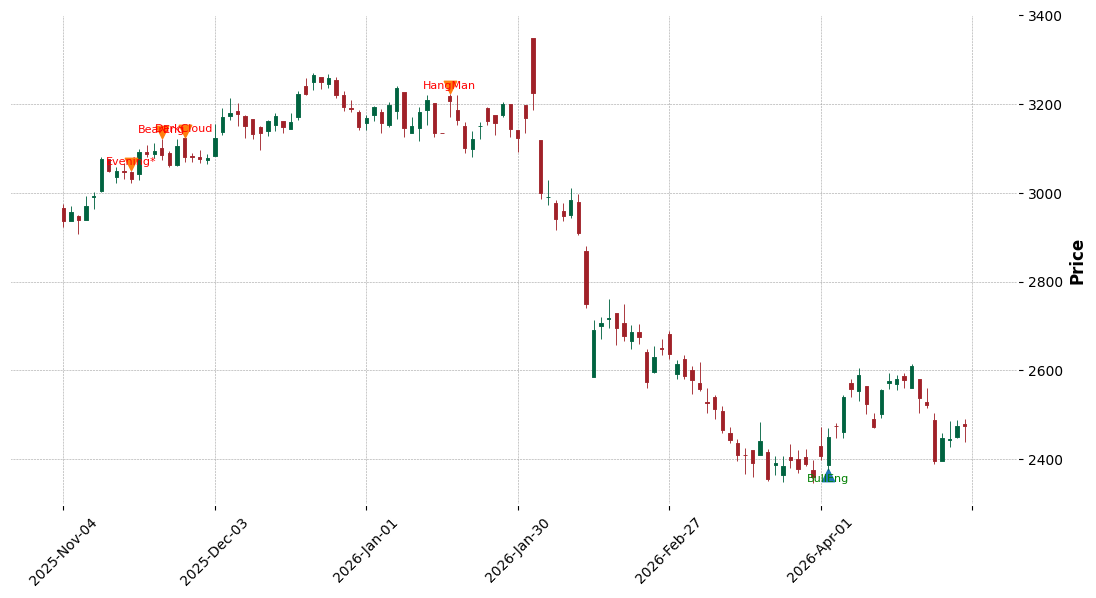

In [9]:
lot = 0
lot_size = 200
analysis(lot, lot_size, claude=0)

## Claude

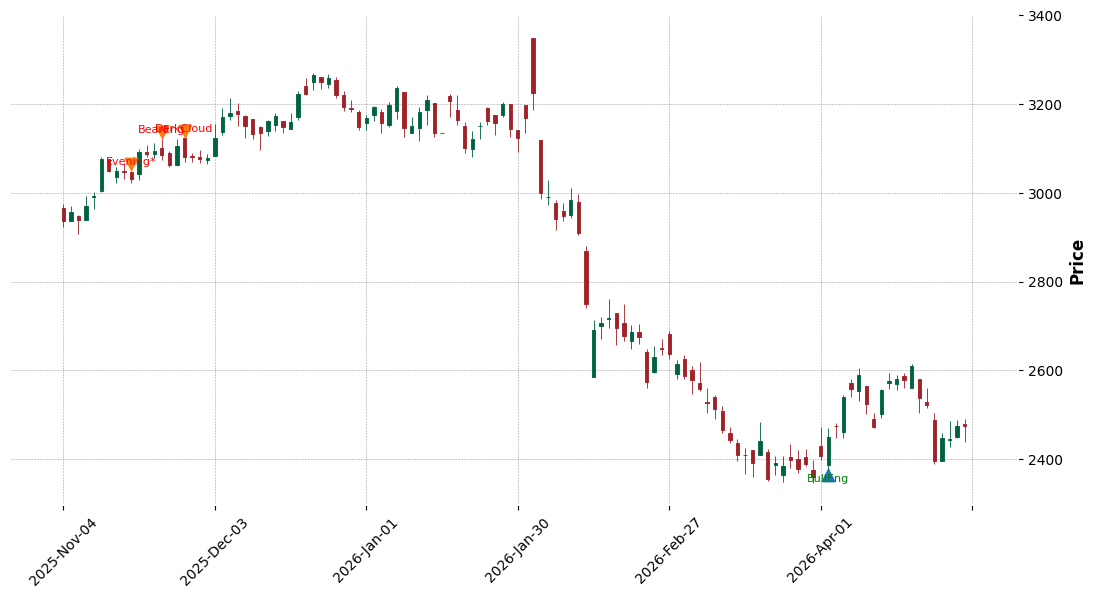

In [10]:
lot = 0
lot_size = 200
analysis(lot, lot_size, claude=1)

## Both

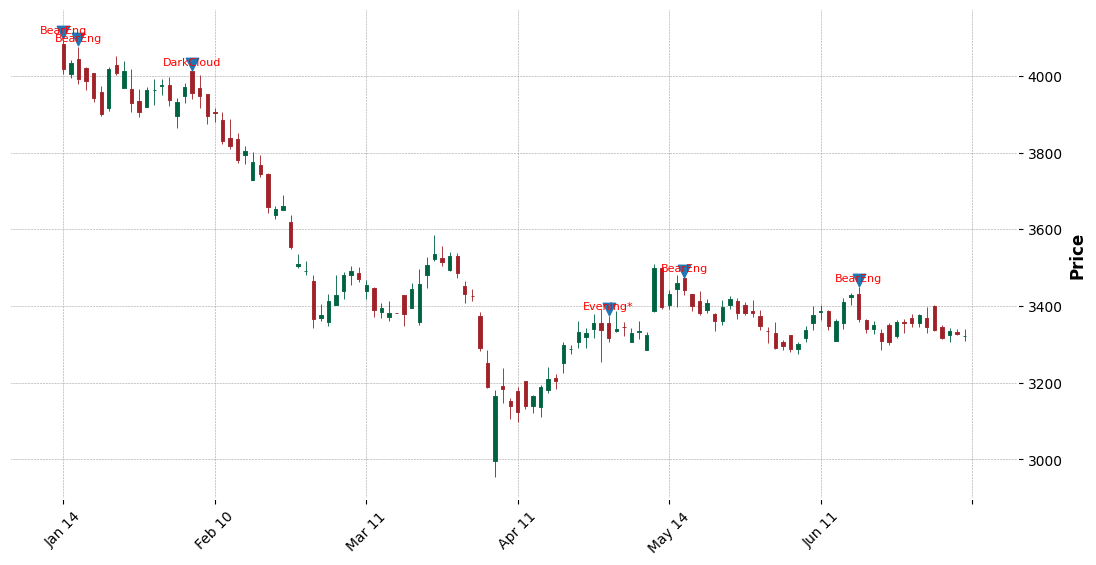

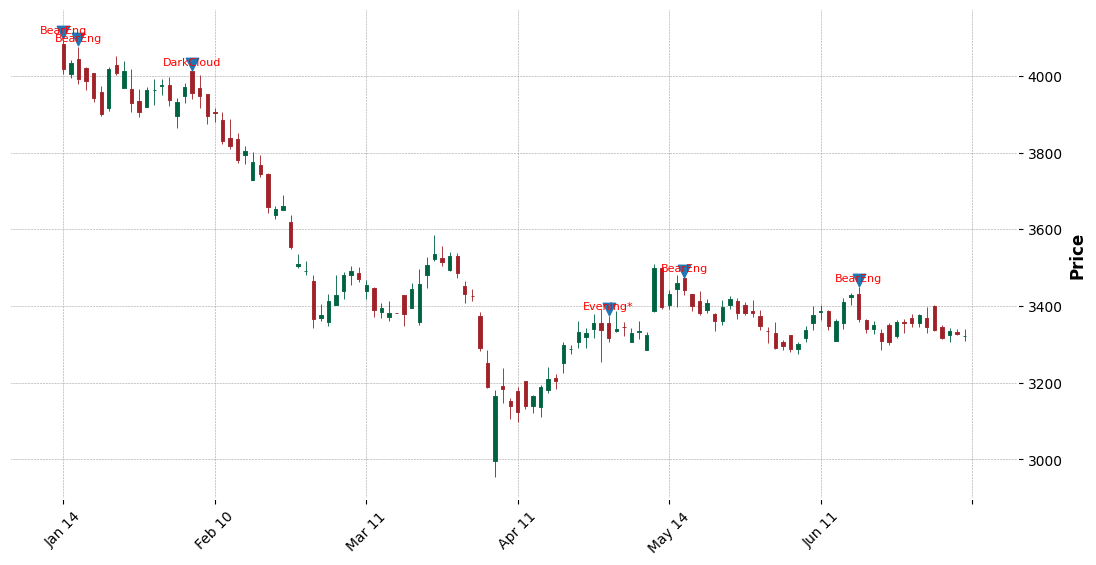

In [12]:
lot = 1
lot_size = 200

analysis(lot, lot_size, claude=0)
analysis(lot, lot_size, claude=1)
